# Survival Rate Decomposition Analysis

Why does **Extension** beat single-proposer methods? We answer with four plots.

**Definitions**

* Survival rate $A(p) = P(L_i \ge p)$ — fraction of steps that reach at least position $p$. Area under $A$ equals MAT (mean accepted tokens). $A(p)$ also equals the cumulative product of conditional acceptances $a_j = P(j\,\text{accepted} \mid j-1\,\text{accepted})$ — collapse at any $a_j$ collapses the whole chain.
* Anchor depth $k$ — number of EAGLE backbone tokens accepted in the step (the branch point where Extension takes over).
* Extension length $\tau$ — tokens accepted in the suffix tail above the anchor. Total: $L_i = k_i + \tau_i$.

**Decomposition**

$$A(p) = \sum_k P(\text{anchor}=k) \cdot A_{\text{sfx-anchor}}(p-k \mid k).$$

**Traces** (collected by `simulation/scripts/compute_method_depth_rates.py` via `--trace` histograms in `method_depth_<wl>_s8k8.json`):

* Trace A — Extension run: per step `(k, τ)` → `anchor_hist` and `anchor_tau_hist[k]`.
* Trace B — EAGLE-only run: per step `L_eagle` → `L_eagle_hist`.
* Trace C — Suffix-only run: per step `L_suffix` → `L_suffix_hist`.

Same dataset partition for all three traces (collected together per step).

**Notes**
* Suffix cache is updated by exactly one bonus token per step (no draft-acceptance pollution).
* Acceptance is **survival**: a position $p$ counts as accepted only if $1 .. p$ all accepted (rejection upstream → reject downstream).
* Steps with $k \ge 9$ are excluded (max_b = 8 reslice cap).

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

ROOT = Path('/home/muchwater/advance-spec/simulation/results')
EXPL = ROOT / 'explorations'
OUT_DIR = Path('/home/muchwater/advance-spec/simulation/notebooks/figures')
OUT_DIR.mkdir(exist_ok=True, parents=True)

WORKLOADS = ['specbench', 'bfcl_v4', 'swebench_verified']
WORKLOAD_LABEL = {
    'specbench':         'SpecBench',
    'bfcl_v4':           'BFCLv4',
    'swebench_verified': 'SWE-Bench Verified',
}
RESLICE = 's8k8'

# 9-step sequential colormap for k = 0..8 (used in Plot 2 and Plot 3).
K_VALUES = list(range(9))
K_CMAP = cm.get_cmap('viridis', len(K_VALUES))
K_COLORS = [K_CMAP(i) for i in range(len(K_VALUES))]

# Plot 4 method colors (separate from k colormap).
METHOD_COLORS = {
    'EAGLE-3':   '#d62728',
    'Suffix':    '#1f77b4',
    'Extension': '#000000',
}

plt.rcParams.update({
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'savefig.dpi':     300,
    'figure.dpi':      120,
})

In [2]:
# Load traces from method_depth_<wl>_s8k8.json. Trace A = (anchor_hist,
# anchor_tau_hist), Trace B = L_eagle_hist, Trace C = L_suffix_hist,
# plus L_extension_hist for cross-checking Plot 4.

def load_trace(wl):
    p = EXPL / f'method_depth_{wl}_{RESLICE}.json'
    if not p.exists():
        return None
    with open(p) as f:
        d = json.load(f)
    return d.get('trace')

traces = {wl: load_trace(wl) for wl in WORKLOADS}
for wl in WORKLOADS:
    t = traces[wl]
    if t is None:
        print(f'  {wl}: trace NOT YET present')
    else:
        print(f'  {wl}: {t["n_steps"]} steps, k_overflow={t.get("n_excluded_k_overflow", 0)}, tau_overflow={t.get("n_excluded_tau_overflow", 0)}')

def survival_from_hist(hist):
    """Convert a length-histogram to survival rate A(p) = P(L >= p).
    hist[i] = number of steps with L = i. Returns array of length
    len(hist), where A[p] = P(L >= p)."""
    arr = np.array(hist, dtype=float)
    n = arr.sum()
    if n == 0:
        return np.zeros(len(arr))
    # cumulative tail: A[p] = sum_{i >= p} hist[i] / n
    tail = np.cumsum(arr[::-1])[::-1] / n
    return tail

  specbench: 134927 steps, k_overflow=0, tau_overflow=0
  bfcl_v4: 46308 steps, k_overflow=0, tau_overflow=0
  swebench_verified: 188675 steps, k_overflow=0, tau_overflow=0


## Plot 1 — Anchor distribution $P(\text{anchor} = k)$

How often does Extension branch off at each backbone depth $k$?

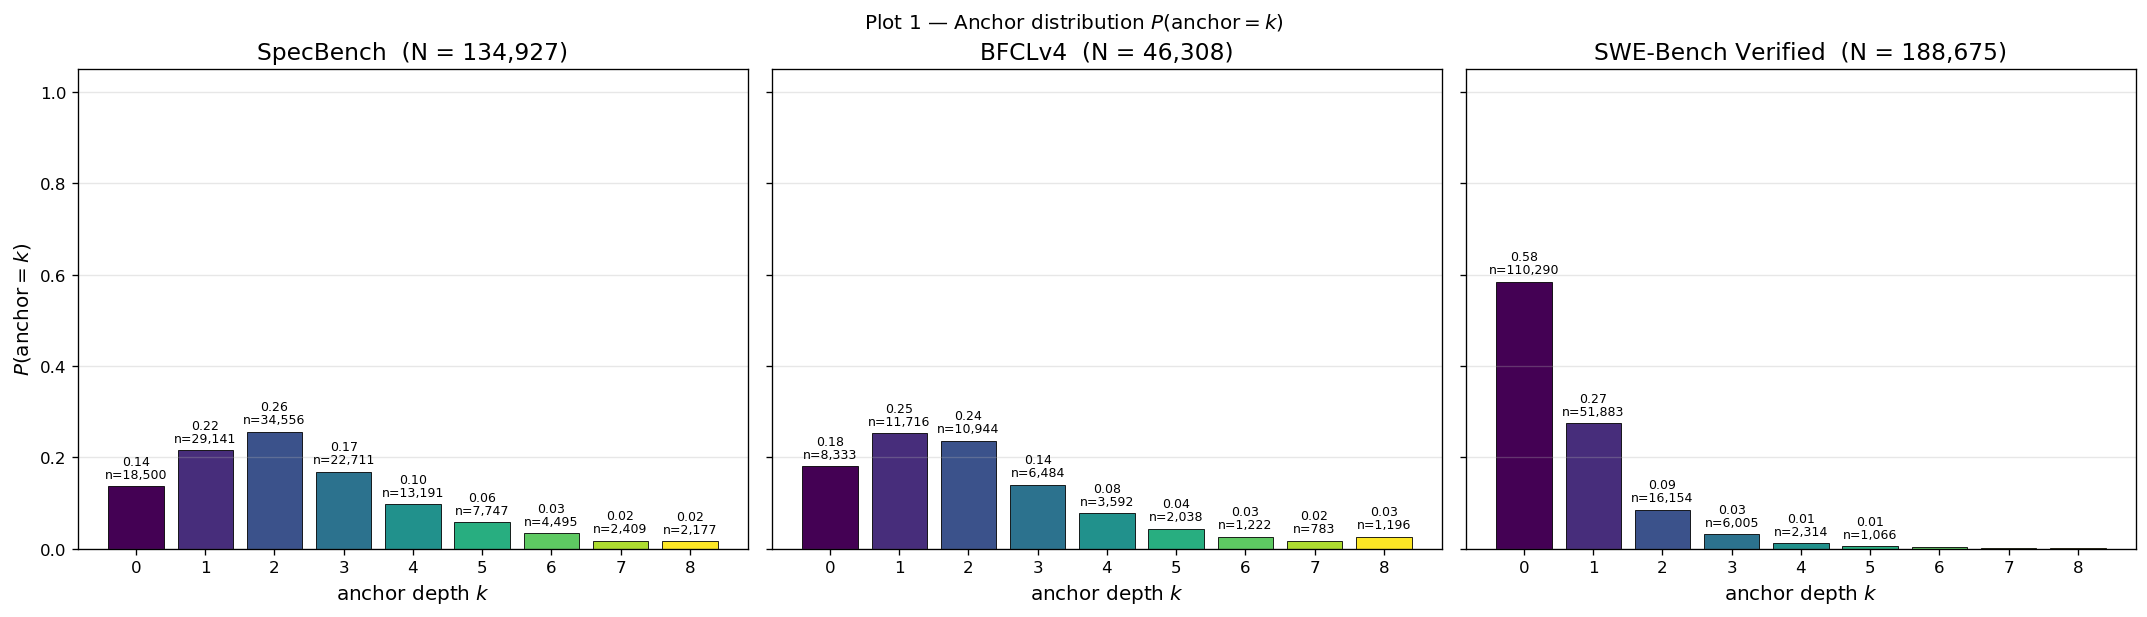

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ci, wl in enumerate(WORKLOADS):
    ax = axes[ci]
    t = traces[wl]
    if t is None:
        ax.text(0.5, 0.5, f'{WORKLOAD_LABEL[wl]}: missing',
                ha='center', va='center', transform=ax.transAxes)
        continue
    h = np.array(t['anchor_hist'], dtype=float)
    total = h.sum()
    p_k = h / max(total, 1)
    bars = ax.bar(K_VALUES, p_k[:len(K_VALUES)],
                  color=K_COLORS, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('anchor depth $k$')
    if ci == 0:
        ax.set_ylabel('$P(\\mathrm{anchor} = k)$')
    ax.set_title(f'{WORKLOAD_LABEL[wl]}  (N = {int(total):,})')
    ax.set_xticks(K_VALUES)
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis='y', alpha=0.3)
    # Annotate fraction + raw count so sparse k bins are visible.
    for x, v, c in zip(K_VALUES, p_k[:len(K_VALUES)], h[:len(K_VALUES)]):
        if v > 0.005:
            ax.text(x, v + 0.012,
                    f'{v:.2f}\nn={int(c):,}',
                    ha='center', va='bottom', fontsize=7.5,
                    linespacing=1.0)
fig.suptitle(r'Plot 1 — Anchor distribution $P(\mathrm{anchor} = k)$', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot1_anchor_distribution.png', bbox_inches='tight')
plt.show()

## Plot 1(a/b/c) — Accept-token distribution per single method

Distribution $P(L = l)$ of total accepted tokens per step, for each method run *standalone*. Plot 1 above used $P(\text{anchor}=k)$ which is the extension run's anchor depth (capped at $k=8$). The panels below use the full standalone walk lengths from `L_eagle_hist`, `L_suffix_hist`, `L_extension_hist` — same dataset, three separate proposers.

In [ ]:
PLOT1_PANELS = [
    ('a', 'L_eagle_hist',     'EAGLE-3',   '#d62728', 'plot1a_accept_dist_eagle3.png',    16),
    ('b', 'L_suffix_hist',    'Suffix',    '#1f77b4', 'plot1b_accept_dist_suffix.png',    20),
    ('c', 'L_extension_hist', 'Extension', '#000000', 'plot1c_accept_dist_extension.png', 24),
]

for tag, key, name, color, fname, max_x in PLOT1_PANELS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ci, wl in enumerate(WORKLOADS):
        ax = axes[ci]
        t = traces[wl]
        if t is None:
            ax.text(0.5, 0.5, f'{WORKLOAD_LABEL[wl]}: missing',
                    ha='center', va='center', transform=ax.transAxes)
            continue
        h = np.array(t[key], dtype=float)
        n = h.sum()
        # Lump tail beyond max_x into the last bin so probability mass conserves.
        hh = h.copy()
        if len(hh) > max_x + 1:
            hh[max_x] = hh[max_x:].sum()
            hh = hh[:max_x + 1]
        p_l = hh / n if n else hh
        xs = np.arange(len(p_l))
        ax.bar(xs, p_l, color=color, edgecolor='black', linewidth=0.4, alpha=0.85)
        ax.set_xlabel('accepted tokens $L$')
        if ci == 0:
            ax.set_ylabel(f'$P(L = l)$ — {name}')
        mean = (h * np.arange(len(h))).sum() / max(n, 1)
        ax.set_title(f'{WORKLOAD_LABEL[wl]}  (N = {int(n):,},  mean $L$ = {mean:.2f})')
        ax.set_xlim(-0.5, max_x + 0.5)
        ax.set_ylim(0, max(0.05, p_l.max() * 1.15))
        # Explicit per-integer ticks so the bin index is always readable.
        ax.set_xticks(xs)
        ax.set_xticklabels([str(int(x)) for x in xs], fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)
        for x, v in zip(xs, p_l):
            if v >= 0.05:
                ax.text(x, v + p_l.max() * 0.015, f'{v:.2f}',
                        ha='center', va='bottom', fontsize=7.5)
    fig.suptitle(f'Plot 1({tag}) — {name} accept token distribution $P(L = l)$', y=1.02)
    plt.tight_layout()
    plt.savefig(OUT_DIR / fname, bbox_inches='tight')
    plt.show()

## Plot 2 — Conditional extension survival $A(\tau \mid k)$

For each anchor depth $k$, what fraction of steps with that anchor reach extension length $\tau$ or more? **Different denominators** per curve (= number of steps with anchor exactly $k$).

Higher curves = the extension is more reliable when started from that anchor depth (selection-bias evidence: deeper $k$ steps tend to be 'easier').

In [ ]:
MAX_P = 24  # extend a bit beyond max_b + max_e edge

# Each k-band has two regimes:
#   p ≤ k  → anchor plateau, height = P(anchor=k) (backbone-guaranteed)
#   p > k  → extension decay,  height = P(anchor=k) · P(τ ≥ p-k | anchor=k)
# Render the extension regime slightly lighter so the split is
# visible without overwhelming the figure.
ANCHOR_ALPHA = 0.95
EXT_ALPHA    = 0.65

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ci, wl in enumerate(WORKLOADS):
    ax = axes[ci]
    t = traces[wl]
    if t is None:
        ax.text(0.5, 0.5, f'{WORKLOAD_LABEL[wl]}: missing',
                ha='center', va='center', transform=ax.transAxes)
        continue
    n_total = t['n_steps']
    tau_hist = np.array(t['anchor_tau_hist'], dtype=float)
    bands = np.zeros((len(K_VALUES), MAX_P + 1))
    n_per_k = np.zeros(len(K_VALUES), dtype=int)
    for k in K_VALUES:
        n_k = int(tau_hist[k].sum())
        n_per_k[k] = n_k
        if n_k == 0 or n_total == 0:
            continue
        L_hist_k = np.zeros(MAX_P + 1)
        for tau, cnt in enumerate(tau_hist[k]):
            L = k + tau
            if L <= MAX_P:
                L_hist_k[L] += cnt
        survival_given_k = survival_from_hist(L_hist_k)
        bands[k] = (n_k / n_total) * survival_given_k

    ps = np.arange(MAX_P + 1)
    cumulative = np.zeros(MAX_P + 1)
    for k in K_VALUES:
        if bands[k].sum() == 0:
            continue
        # Anchor portion (p ≤ k): solid; skipped for k=0 (no backbone).
        if k >= 1:
            ps_a = ps[:k + 1]
            ax.fill_between(
                ps_a, cumulative[:k + 1], cumulative[:k + 1] + bands[k][:k + 1],
                color=K_COLORS[k], alpha=ANCHOR_ALPHA,
                edgecolor='white', linewidth=0.4,
                label=f'$k = {k}$  (n={n_per_k[k]:,})',
            )
        # Extension portion (p ≥ k): slightly lighter.
        ps_e = ps[k:]
        ax.fill_between(
            ps_e, cumulative[k:], cumulative[k:] + bands[k][k:],
            color=K_COLORS[k], alpha=EXT_ALPHA,
            edgecolor='white', linewidth=0.4,
            label=(f'$k = {k}$  (n={n_per_k[k]:,})' if k == 0 else None),
        )
        cumulative += bands[k]
    ax.plot(ps, cumulative, color='black', linewidth=1.6, linestyle='--',
            label=r'$A(p)$ total')
    ax.set_xlabel('position $p$')
    if ci == 0:
        ax.set_ylabel('survival rate $A(p)$')
    ax.set_title(f'{WORKLOAD_LABEL[wl]}  (N = {n_total:,})')
    ax.set_ylim(0, 1.0)
    ax.set_xlim(0, MAX_P)
    ax.set_xticks(np.arange(0, MAX_P + 1, 2))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, ncol=2,
              title='anchor $k$  (sample $n_k$)', title_fontsize=9)
fig.suptitle(r'Plot 3 — Stacked decomposition: dark = anchor (p $\leq$ k),' +
             r'  light = extension (p > k)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot3_stacked_decomposition.png', bbox_inches='tight')
plt.show()

## Plot 3 — Stacked decomposition (Convention 2: Total-length view)

Stack $A(p)$ as anchor-depth contributions. Convention 2 (default):

$$\text{band}_k(p) = P(\text{anchor}=k) \cdot P(L_i \ge p \mid \text{anchor}=k)$$

where $L_i = k + \tau_i$ is the total length, so band $k$ contributes only at $p \ge 0$ (and reduces to $P(\text{anchor}=k)$ at $p = 0$). Late positions are mostly held up by deep-$k$ bands.

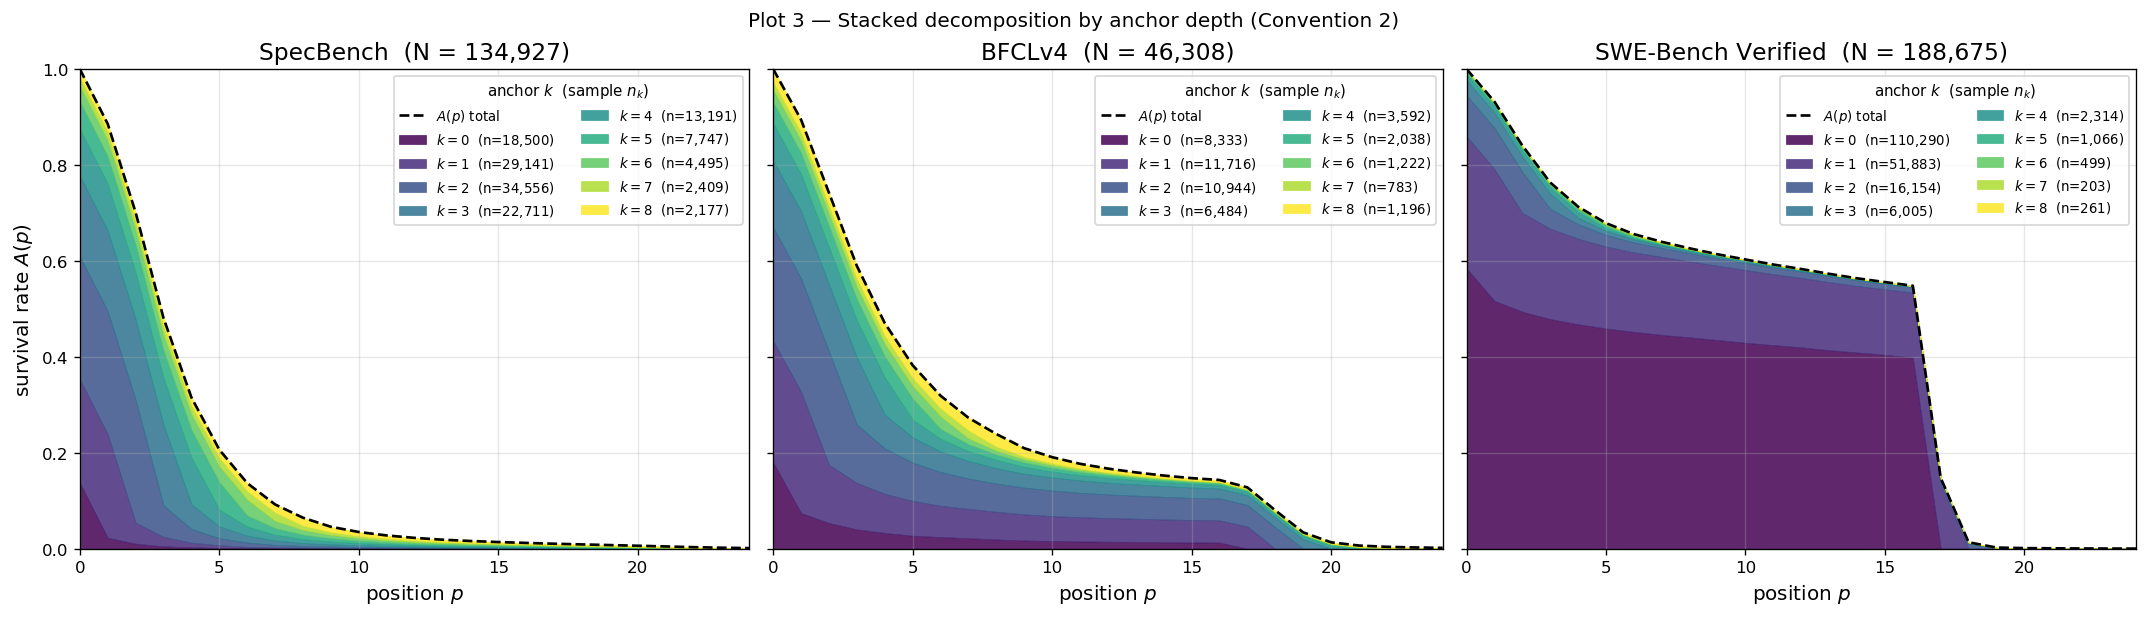

In [5]:
MAX_P = 24  # extend a bit beyond max_b + max_e edge

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ci, wl in enumerate(WORKLOADS):
    ax = axes[ci]
    t = traces[wl]
    if t is None:
        ax.text(0.5, 0.5, f'{WORKLOAD_LABEL[wl]}: missing',
                ha='center', va='center', transform=ax.transAxes)
        continue
    n_total = t['n_steps']
    tau_hist = np.array(t['anchor_tau_hist'], dtype=float)  # K_BIN x TAU_BIN
    # For each k, build histogram of total length L = k + tau:
    bands = np.zeros((len(K_VALUES), MAX_P + 1))
    n_per_k = np.zeros(len(K_VALUES), dtype=int)
    for k in K_VALUES:
        n_k = int(tau_hist[k].sum())
        n_per_k[k] = n_k
        if n_k == 0 or n_total == 0:
            continue
        # P(L >= p | anchor=k) for p = 0..MAX_P
        L_hist_k = np.zeros(MAX_P + 1)
        for tau, cnt in enumerate(tau_hist[k]):
            L = k + tau
            if L <= MAX_P:
                L_hist_k[L] += cnt
        survival_given_k = survival_from_hist(L_hist_k)
        # Convention 2: band_k(p) = P(anchor=k) * P(L >= p | anchor=k)
        bands[k] = (n_k / n_total) * survival_given_k
    ps = np.arange(MAX_P + 1)
    cumulative = np.zeros(MAX_P + 1)
    for k in K_VALUES:
        ax.fill_between(ps, cumulative, cumulative + bands[k],
                        color=K_COLORS[k], alpha=0.85, edgecolor='white',
                        linewidth=0.4,
                        label=f'$k = {k}$  (n={n_per_k[k]:,})')
        cumulative += bands[k]
    # Total survival overlay (sum over k = full A(p))
    ax.plot(ps, cumulative, color='black', linewidth=1.6, linestyle='--',
            label=r'$A(p)$ total')
    ax.set_xlabel('position $p$')
    if ci == 0:
        ax.set_ylabel('survival rate $A(p)$')
    ax.set_title(f'{WORKLOAD_LABEL[wl]}  (N = {n_total:,})')
    ax.set_ylim(0, 1.0)
    ax.set_xlim(0, MAX_P)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, ncol=2,
              title='anchor $k$  (sample $n_k$)', title_fontsize=9)
fig.suptitle(r'Plot 3 — Stacked decomposition by anchor depth (Convention 2)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot3_stacked_decomposition.png', bbox_inches='tight')
plt.show()

## Plot 4 — Extension vs each single proposer

Compare $A(p)$ for EAGLE-3 alone, Suffix alone, and Extension. Extension's curve should sit above the envelope of the two single-proposer curves (and the gap should grow at later $p$).

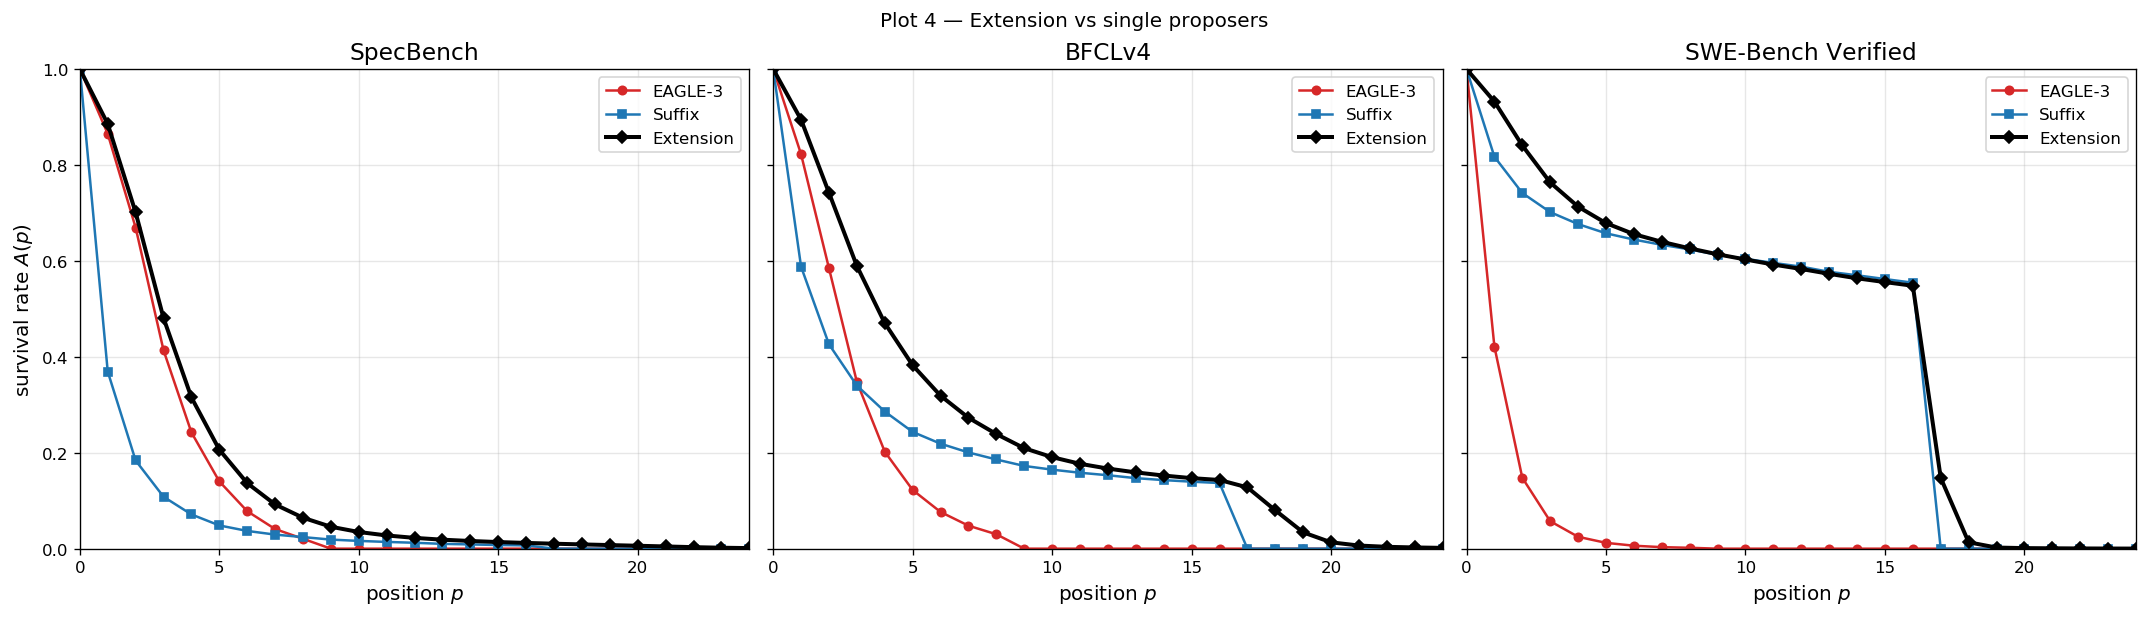

In [6]:
MAX_P_4 = 24

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ci, wl in enumerate(WORKLOADS):
    ax = axes[ci]
    t = traces[wl]
    if t is None:
        ax.text(0.5, 0.5, f'{WORKLOAD_LABEL[wl]}: missing',
                ha='center', va='center', transform=ax.transAxes)
        continue
    A_eagle = survival_from_hist(t['L_eagle_hist'])
    A_suffix = survival_from_hist(t['L_suffix_hist'])
    A_ext = survival_from_hist(t['L_extension_hist'])
    ps_e = np.arange(min(len(A_eagle), MAX_P_4 + 1))
    ps_s = np.arange(min(len(A_suffix), MAX_P_4 + 1))
    ps_x = np.arange(min(len(A_ext), MAX_P_4 + 1))
    ax.plot(ps_e, A_eagle[:len(ps_e)], color=METHOD_COLORS['EAGLE-3'],
            marker='o', markersize=5, linewidth=1.5, label='EAGLE-3')
    ax.plot(ps_s, A_suffix[:len(ps_s)], color=METHOD_COLORS['Suffix'],
            marker='s', markersize=5, linewidth=1.5, label='Suffix')
    ax.plot(ps_x, A_ext[:len(ps_x)], color=METHOD_COLORS['Extension'],
            marker='D', markersize=5, linewidth=2.4, label='Extension')
    ax.set_xlabel('position $p$')
    if ci == 0:
        ax.set_ylabel('survival rate $A(p)$')
    ax.set_title(WORKLOAD_LABEL[wl])
    ax.set_ylim(0, 1.0)
    ax.set_xlim(0, MAX_P_4)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
fig.suptitle('Plot 4 — Extension vs single proposers', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot4_extension_vs_single.png', bbox_inches='tight')
plt.show()

## Read-off — $A(p)$ at $p \in \{1, 3, 5, 7\}$

Use this table to populate the slide that previously had illustrative `0.14 / 0.12 / 0.42` numbers.

In [7]:
READ_OFF_PS = [1, 3, 5, 7]
rows = []
for wl in WORKLOADS:
    t = traces[wl]
    if t is None:
        continue
    A_e = survival_from_hist(t['L_eagle_hist'])
    A_s = survival_from_hist(t['L_suffix_hist'])
    A_x = survival_from_hist(t['L_extension_hist'])
    for p in READ_OFF_PS:
        rows.append({
            'workload':  WORKLOAD_LABEL[wl],
            'p':         p,
            'EAGLE-3':   A_e[p] if p < len(A_e) else float('nan'),
            'Suffix':    A_s[p] if p < len(A_s) else float('nan'),
            'Extension': A_x[p] if p < len(A_x) else float('nan'),
        })
if rows:
    df = pd.DataFrame(rows)
    pivot = df.set_index(['workload', 'p'])[['EAGLE-3', 'Suffix', 'Extension']]
    print(pivot.round(3).to_string())
else:
    print('No traces yet.')

                      EAGLE-3  Suffix  Extension
workload           p                            
SpecBench          1    0.865   0.369      0.886
                   3    0.414   0.108      0.481
                   5    0.140   0.048      0.206
                   7    0.041   0.029      0.092
BFCLv4             1    0.822   0.588      0.894
                   3    0.348   0.340      0.589
                   5    0.122   0.243      0.382
                   7    0.048   0.201      0.273
SWE-Bench Verified 1    0.421   0.817      0.932
                   3    0.057   0.702      0.763
                   5    0.012   0.657      0.679
                   7    0.003   0.633      0.640
